# Lab 11: Visualizing Time Series Data

## Dataset Description
- **Dataset**: Daily Minimum Temperatures in Melbourne (1981–1990)
- **Source**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Daily+Minimum+Temperatures+in+Melbourne)
- **Rows**: 3650
- **Columns**: 2 (`Date`, `Temp`)
- Time interval: Daily

---

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import lag_plot, autocorrelation_plot

# Load dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


### 1. Line Plot
- **Features used**: `Date` vs `Temp`
- **Insight**: There is an apparent seasonal trend that repeats each year.

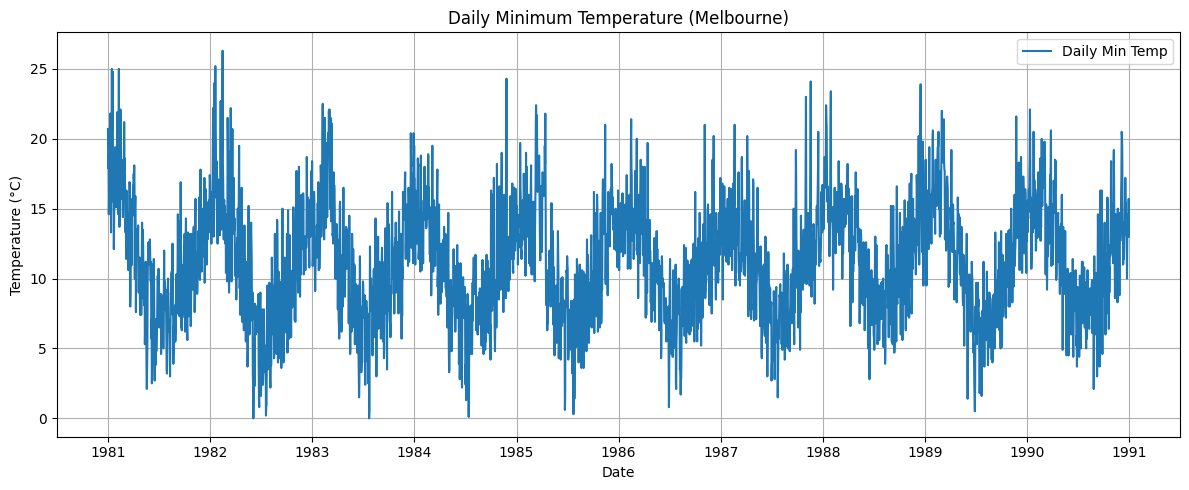

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Temp'], label='Daily Min Temp')
plt.title('Daily Minimum Temperature (Melbourne)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2. Seasonal Decomposition
- **Insight**: The seasonal component clearly shows a yearly cycle.

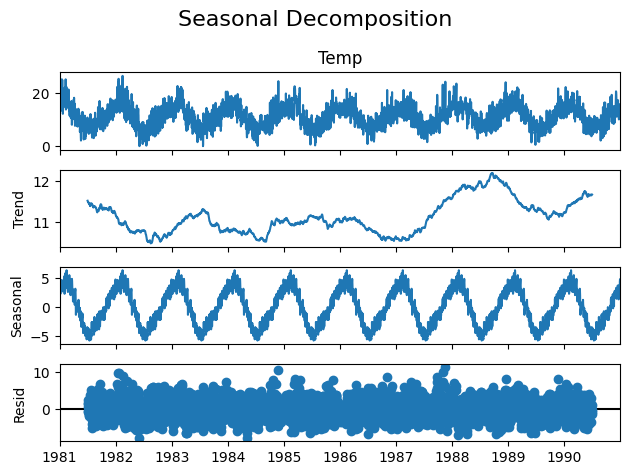

In [18]:
decomposition = seasonal_decompose(df['Temp'], model='additive', period=365)
decomposition.plot()
plt.suptitle('Seasonal Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

### 3. Bar Chart
- **Insight**: July has the lowest average temperature, confirming the winter season in Melbourne.

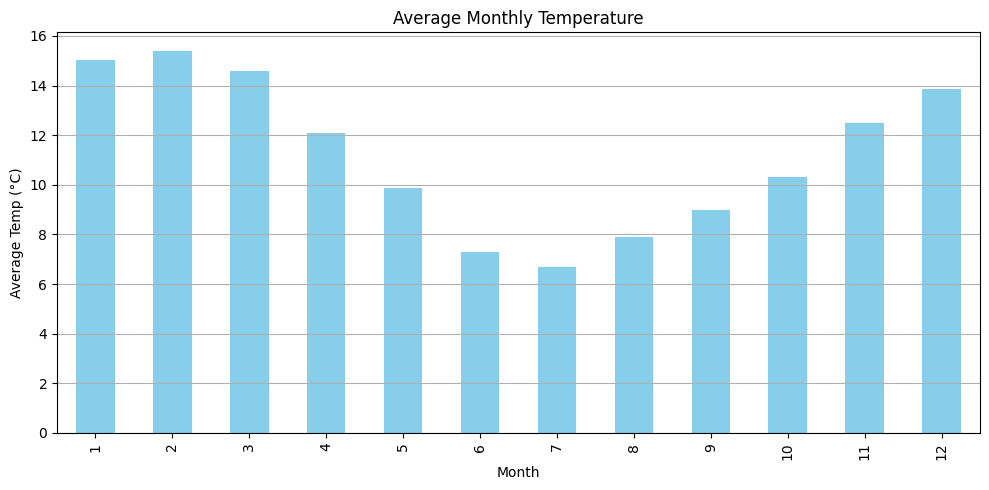

In [19]:
df['Month'] = df.index.month
monthly_avg = df.groupby('Month')['Temp'].mean()
monthly_avg.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temp (°C)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 4. Calendar Heatmap
- **Insight**: Clearly shows colder periods mid-year and warmer ones around the start and end.

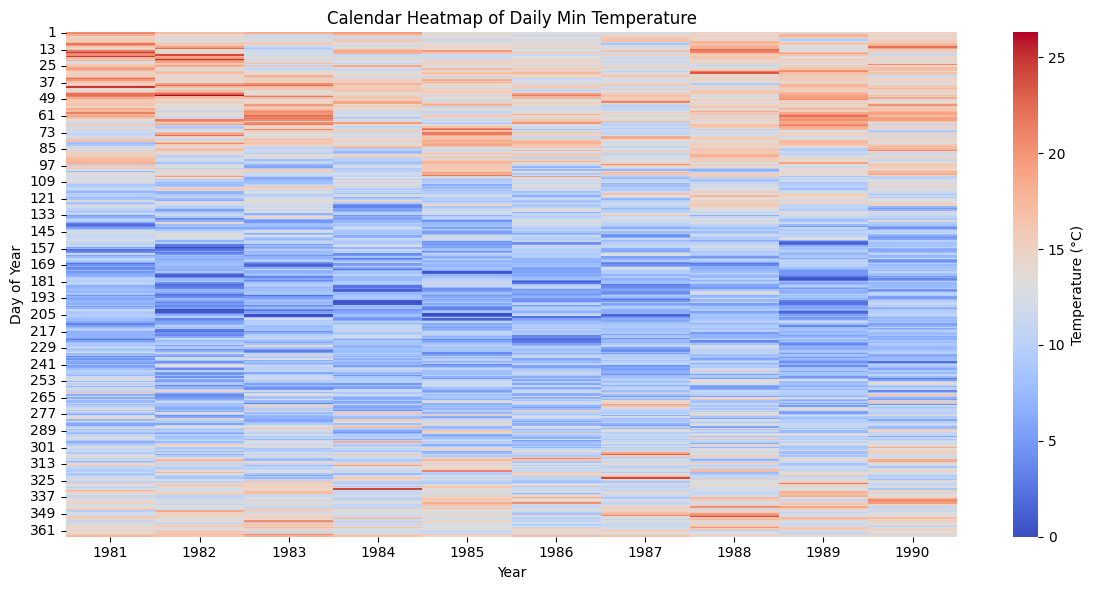

In [20]:
df['Year'] = df.index.year
df['DayOfYear'] = df.index.dayofyear
pivot = df.pivot(index='DayOfYear', columns='Year', values='Temp')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', cbar_kws={'label': 'Temperature (°C)'})
plt.title('Calendar Heatmap of Daily Min Temperature')
plt.xlabel('Year')
plt.ylabel('Day of Year')
plt.tight_layout()
plt.show()

### 5. Autocorrelation Plot
- **Insight**: Significant autocorrelation at lag 365 indicates yearly seasonality.

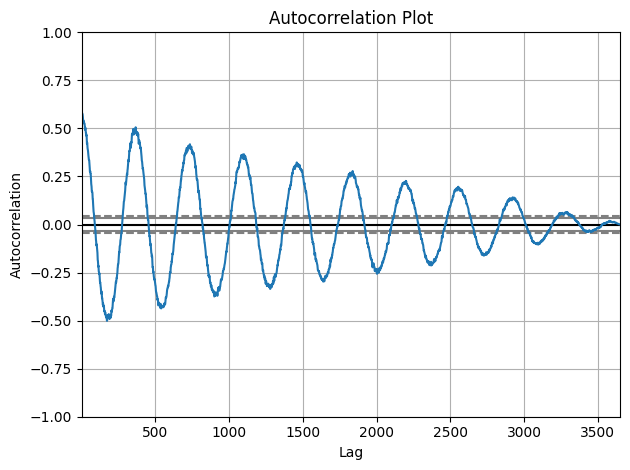

In [21]:
autocorrelation_plot(df['Temp'])
plt.title('Autocorrelation Plot')
plt.tight_layout()
plt.show()

### 6. Lag Plot
- **Insight**: Positive linearity indicates persistence in daily temperature trends.

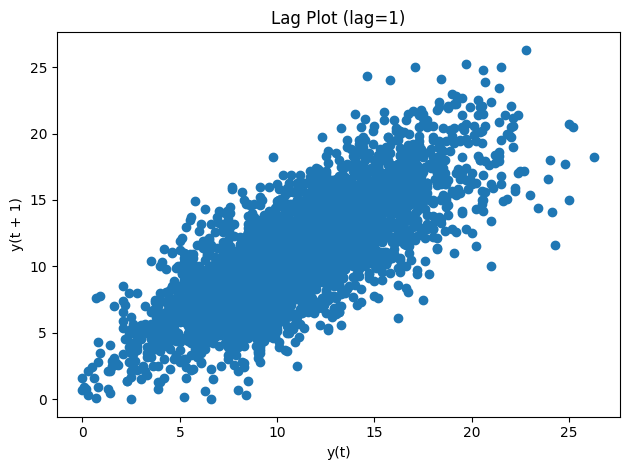

In [22]:
lag_plot(df['Temp'], lag=1)
plt.title('Lag Plot (lag=1)')
plt.tight_layout()
plt.show()